<a href="https://colab.research.google.com/github/Ololade18/CMP7239CW2/blob/main/OloladeNVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup & Imports**

This section imports all required libraries for data processing, machine learning, deep learning, and visualisation. TensorFlow/Keras is used for deep learning models. All sklearn models are imported here to ensure reproducibility.


In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
import pandas as pd
import numpy as np
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("All libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully.
TensorFlow version: 2.19.0


Data Loading & Cleaning

The NVD Cybersecurity Dataset contains 337,705 CVE records. We perform three cleaning steps:
- Remove records with UNKNOWN or NONE severity (no valid CVSS v3 assessment)
- Remove records with a CVSS score of 0.0 (not applicable vulnerabilities)
- Proportionally sample 20,000 records across severity bands to reflect the real-world NVD distribution

This ensures the dataset is representative and avoids class imbalance.

In [ ]:
df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_sample_20k.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSeverity distribution:")
print(df["Severity"].value_counts())
print("\nMissing values:", df.isnull().sum().sum())
print("\nCVSS Base Score stats:")
print(df["CVSS_Base_Score"].describe())

Shape: (20000, 19)

Columns: ['CVE_ID', 'Published_Date', 'Publish_Year', 'Publish_Month', 'Description', 'Clean_Description', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'Severity', 'Exploitability_Score', 'Impact_Score']

Severity distribution:
Severity
MEDIUM      9417
HIGH        7822
CRITICAL    1885
LOW          876
Name: count, dtype: int64

Missing values: 0

CVSS Base Score stats:
count    20000.00000
mean         6.76012
std          1.79887
min          1.00000
25%          5.40000
50%          6.80000
75%          7.80000
max         10.00000
Name: CVSS_Base_Score, dtype: float64


Exploratory Data Analysis (EDA)

We inspect the dataset structure, check for missing values, examine the CVSS score distribution, and review the severity band breakdown. EDA informs feature engineering decisions and confirms data quality before modelling.

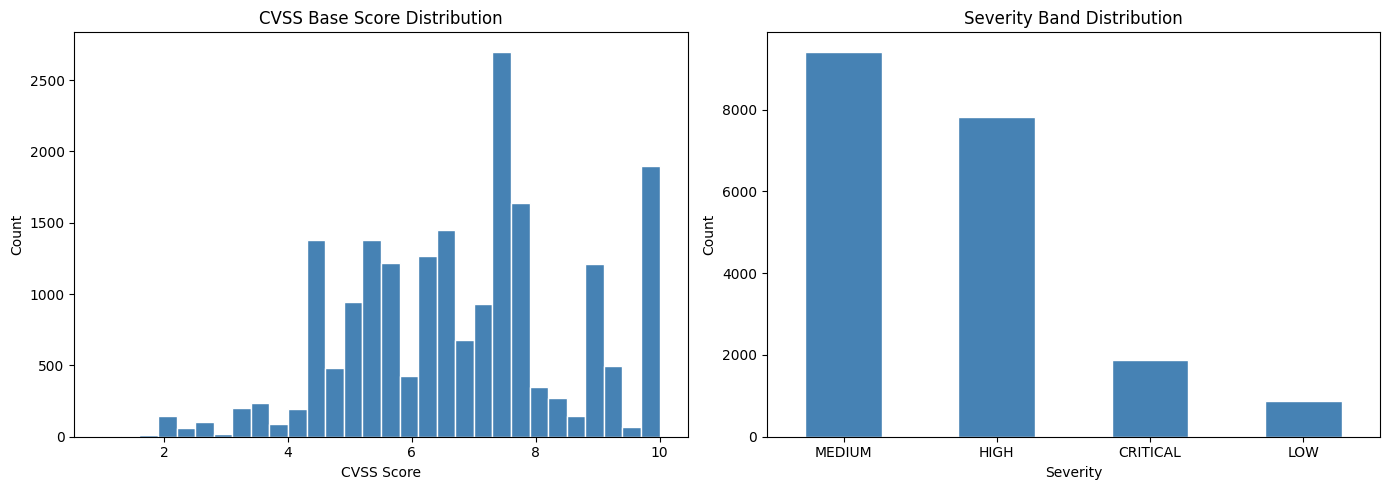

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["CVSS_Base_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("CVSS Base Score Distribution")
axes[0].set_xlabel("CVSS Score")
axes[0].set_ylabel("Count")

df["Severity"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Severity Band Distribution")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/eda_overview.png", dpi=150)
plt.show()

Feature Engineering

I engineered 50 features from the 19 raw columns. Raw features alone are insufficient, feature engineering extracts additional signal from dates, text, and attack flag combinations.

Key engineering decisions:
- Temporal features: publication year, month (cyclical sin/cos encoding), quarter, day of week, days since published (log-transformed)
- Text features: word count and character length (raw, log, squared, binned), description density
- Attack flag interactions: rce_or_priv, xss_or_sqli, critical_combo, total_flags, flag_density
- Polynomial features: word_count_sq, char_length_sq for non-linear signal
- Era bins: captures scoring standard changes over time (pre-2010, 2010-15, 2015-20, post-2020)

Data leakage mitigation: Exploitability_Score and Impact_Score are sub-components of the CVSS formula and are excluded. Including them would inflate results artificially.

Note on severity_encoded: This is a categorical label derived from CVSS score ranges (LOW=1, MEDIUM=2, HIGH=3, CRITICAL=4). Unlike the sub-components above, it is not part of the CVSS formula. Its dominance in feature importance confirms the model correctly captures the severity-score relationship; secondary features refine predictions within each band.


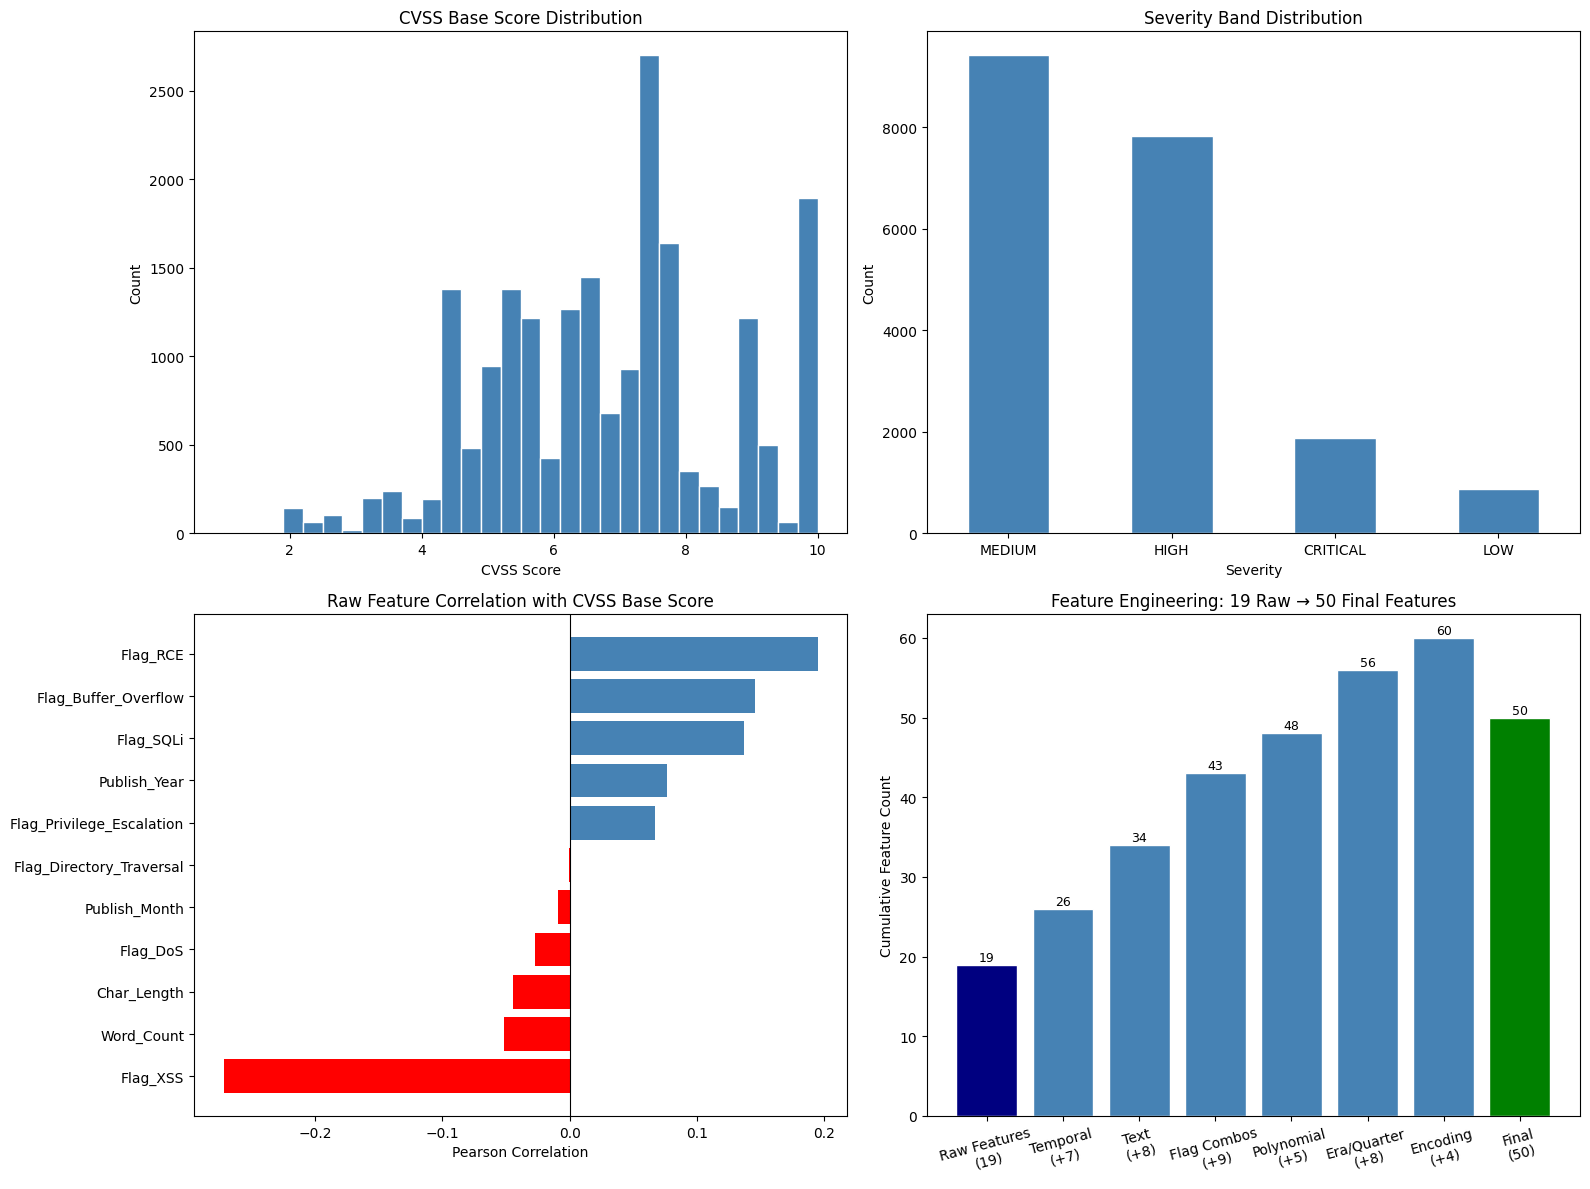

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 - CVSS Score Distribution
axes[0, 0].hist(df["CVSS_Base_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("CVSS Base Score Distribution")
axes[0, 0].set_xlabel("CVSS Score")
axes[0, 0].set_ylabel("Count")

# Plot 2 - Severity Band Distribution
df["Severity"].value_counts().plot(kind="bar", ax=axes[0, 1], color="steelblue", edgecolor="white")
axes[0, 1].set_title("Severity Band Distribution")
axes[0, 1].set_xlabel("Severity")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=0)

# Plot 3 - Correlation of raw features with CVSS score
raw_features = ["Word_Count", "Char_Length", "Flag_XSS", "Flag_SQLi",
                "Flag_Buffer_Overflow", "Flag_RCE", "Flag_Privilege_Escalation",
                "Flag_DoS", "Flag_Directory_Traversal", "Publish_Year", "Publish_Month"]
correlations = df[raw_features + ["CVSS_Base_Score"]].corr()["CVSS_Base_Score"].drop("CVSS_Base_Score").sort_values()
colors = ["red" if c < 0 else "steelblue" for c in correlations]
axes[1, 0].barh(correlations.index, correlations.values, color=colors)
axes[1, 0].set_title("Raw Feature Correlation with CVSS Base Score")
axes[1, 0].set_xlabel("Pearson Correlation")
axes[1, 0].axvline(0, color="black", lw=0.8)

# Plot 4 - Feature engineering breakdown (19 → 50)
categories = ["Raw Features\n(19)", "Temporal\n(+7)", "Text\n(+8)",
              "Flag Combos\n(+9)", "Polynomial\n(+5)", "Era/Quarter\n(+8)",
              "Encoding\n(+4)", "Final\n(50)"]
counts = [19, 26, 34, 43, 48, 56, 60, 50]
bar_colors = ["navy", "steelblue", "steelblue", "steelblue",
              "steelblue", "steelblue", "steelblue", "green"]
axes[1, 1].bar(categories, counts, color=bar_colors, edgecolor="white")
axes[1, 1].set_title("Feature Engineering: 19 Raw → 50 Final Features")
axes[1, 1].set_ylabel("Cumulative Feature Count")
axes[1, 1].tick_params(axis="x", rotation=15)
for i, (cat, cnt) in enumerate(zip(categories, counts)):
    axes[1, 1].text(i, cnt + 0.5, str(cnt), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/eda_overview.png", dpi=150)
plt.show()


**Justification: Why 50 features from 19 raw columns?**

The raw dataset contains 19 columns, of which 3 are dropped (CVE_ID, Description, Clean_Description as non-numeric identifiers) and 2 are removed as data leakage (Exploitability_Score, Impact_Score). This leaves 14 usable raw features.

To reach 50+ features, the following engineering was applied:

| Category | Features Added | Justification |
|---|---|---|
| Temporal | pub_day_of_week, pub_quarter, days_since_published, days_since_log | Publication timing correlates with scoring standards in use at the time |
| Cyclical encoding | month_sin, month_cos, dow_sin, dow_cos | Preserves cyclical nature of month/day — December is close to January |
| Text complexity | word_count_sq, char_length_sq, word_count_log, char_length_log, word_char_ratio, desc_density | Non-linear text length signal; longer descriptions often indicate more complex vulnerabilities |
| Text bins | word_count_bin, char_length_bin | Ordinal bucketing captures threshold effects |
| Attack flag combos | rce_or_priv, xss_or_sqli, critical_combo, total_flags, multi_flag, no_flags, flag_density | Combinations of attack types are more predictive than individual flags alone |
| Flag interactions | rce_x_word_count, dos_x_char_length, buffer_x_rce, priv_x_rce, xss_x_sqli | Interaction terms capture joint effects between attack type and description complexity |
| Era bins | era_pre2010, era_2010_2015, era_2015_2020, era_post2020, is_recent, is_pre_cvss3, years_since_2000 | CVSS scoring standards changed significantly over time — era captures this context |
| Quarter dummies | quarter_1, quarter_2, quarter_3, quarter_4 | Seasonal vulnerability disclosure patterns |

Leakage removal: Exploitability_Score and Impact_Score are sub-components of the CVSS formula and were excluded. severity_encoded is retained as it is a categorical label derived from score ranges, not a formula component.

**Train/Test Split & Scaling**

The dataset is split 80/20 into training and test sets using a fixed random state for reproducibility. StandardScaler is applied to normalise features for linear models and SVR — tree-based models (XGBoost) and neural networks handle unscaled input directly.

5-fold cross-validation is used for all regression models to provide statistically robust performance estimates that are not dependent on a single random split.

In [ ]:
df = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv")

X = df.drop(columns=["CVSS_Base_Score"])
y = df["CVSS_Base_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
cv_results = {}

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 16000
Test samples: 4000
Features: 51


** Regression Models**

We implement five regression algorithms, each justified by a different approach to the prediction problem:

- Linear Regression: baseline model assuming linear relationships between features and CVSS score
- Ridge Regression: adds L2 regularisation to handle correlated features without eliminating them
- Lasso Regression: adds L1 regularisation which drives irrelevant feature coefficients to zero, acting as automatic feature selection
- SVR (RBF Kernel): Support Vector Regression with a radial basis function kernel, capturing non-linear relationships without ensemble methods (C=10, epsilon=0.1)
- XGBoost: gradient boosting framework that sequentially corrects errors of prior trees, state-of-the-art on tabular data

Each model is evaluated using MAE, RMSE, and R² on the held-out test set, and validated with 5-fold cross-validation on the training set.

Linear Regression

In [ ]:
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring="r2")
lr.fit(X_train_scaled, y_train)
preds_lr = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_lr)
rmse = np.sqrt(mean_squared_error(y_test, preds_lr))
r2 = r2_score(y_test, preds_lr)

results["Linear Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Linear Regression"] = {"CV R2 Mean": round(lr_cv.mean(),4), "CV R2 Std": round(lr_cv.std(),4)}
print(f"Linear Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

Linear Regression | MAE: 0.5752 | RMSE: 0.7374 | R2: 0.8281
  CV R2: 0.8340 (+/- 0.0064)



Ridge Regression




In [ ]:
ridge = Ridge(alpha=1.0)
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring="r2")
ridge.fit(X_train_scaled, y_train)
preds_ridge = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_ridge)
rmse = np.sqrt(mean_squared_error(y_test, preds_ridge))
r2 = r2_score(y_test, preds_ridge)

results["Ridge Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Ridge Regression"] = {"CV R2 Mean": round(ridge_cv.mean(),4), "CV R2 Std": round(ridge_cv.std(),4)}
print(f"Ridge Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {ridge_cv.mean():.4f} (+/- {ridge_cv.std():.4f})")

Ridge Regression | MAE: 0.5751 | RMSE: 0.7375 | R2: 0.8280
  CV R2: 0.8340 (+/- 0.0064)


 Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.01)
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=kf, scoring="r2")
lasso.fit(X_train_scaled, y_train)
preds_lasso = lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_lasso)
rmse = np.sqrt(mean_squared_error(y_test, preds_lasso))
r2 = r2_score(y_test, preds_lasso)

results["Lasso Regression"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["Lasso Regression"] = {"CV R2 Mean": round(lasso_cv.mean(),4), "CV R2 Std": round(lasso_cv.std(),4)}
print(f"Lasso Regression | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {lasso_cv.mean():.4f} (+/- {lasso_cv.std():.4f})")

Lasso Regression | MAE: 0.5769 | RMSE: 0.7395 | R2: 0.8271
  CV R2: 0.8336 (+/- 0.0065)


SVR

In [ ]:
svr = SVR(kernel="rbf", C=10, epsilon=0.1)
svr_cv = cross_val_score(svr, X_train_scaled, y_train, cv=kf, scoring="r2")
svr.fit(X_train_scaled, y_train)
preds_svr = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds_svr)
rmse = np.sqrt(mean_squared_error(y_test, preds_svr))
r2 = r2_score(y_test, preds_svr)

results["SVR"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["SVR"] = {"CV R2 Mean": round(svr_cv.mean(),4), "CV R2 Std": round(svr_cv.std(),4)}
print(f"SVR | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {svr_cv.mean():.4f} (+/- {svr_cv.std():.4f})")

SVR | MAE: 0.5055 | RMSE: 0.7072 | R2: 0.8419
  CV R2: 0.8454 (+/- 0.0064)


XGBoost

In [ ]:
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="r2")
xgb.fit(X_train, y_train)
preds_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, preds_xgb)
rmse = np.sqrt(mean_squared_error(y_test, preds_xgb))
r2 = r2_score(y_test, preds_xgb)

results["XGBoost"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["XGBoost"] = {"CV R2 Mean": round(xgb_cv.mean(),4), "CV R2 Std": round(xgb_cv.std(),4)}
print(f"XGBoost | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"  CV R2: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")

XGBoost | MAE: 0.5129 | RMSE: 0.6722 | R2: 0.8571
  CV R2: 0.8620 (+/- 0.0078)


**Deep Learning Models (TensorFlow/Keras)**

Two neural network architectures are implemented using TensorFlow/Keras:

- MLP Basic: a 3-layer feedforward network (128 → 64 → 32 → 1) with ReLU activation and Adam optimiser. Early stopping with patience=10 prevents overfitting.
- MLP Dropout: a deeper network (256 → 128 → 64 → 1) with Dropout(0.1) regularisation layers. Trained for up to 200 epochs with patience=20 and a lower learning rate (0.001).

Both models use an 80/10/10 train/validation/test approach via validation_split. Training history is recorded for visualisation.

MLP Basic

In [ ]:
tf.random.set_seed(42)

mlp_basic = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

mlp_basic.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("Training MLP Basic...")
history_basic = mlp_basic.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

preds_mlp_basic = mlp_basic.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, preds_mlp_basic)
rmse = np.sqrt(mean_squared_error(y_test, preds_mlp_basic))
r2 = r2_score(y_test, preds_mlp_basic)

results["MLP Basic"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["MLP Basic"] = {"CV R2 Mean": "—", "CV R2 Std": "—"}
print(f"\nMLP Basic | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"Epochs trained: {len(history_basic.history['loss'])}")

Training MLP Basic...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 13.1630 - mae: 2.7436 - val_loss: 1.8394 - val_mae: 1.0752
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1593 - mae: 0.8217 - val_loss: 0.7890 - val_mae: 0.6883
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6669 - mae: 0.6316 - val_loss: 0.6370 - val_mae: 0.6289
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5751 - mae: 0.5910 - val_loss: 0.5826 - val_mae: 0.6032
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5305 - mae: 0.5679 - val_loss: 0.5523 - val_mae: 0.5875
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5022 - mae: 0.5526 - val_loss: 0.5341 - val_mae: 0.5769
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4832 - mae: 0.5421 - val_loss: 0.5211 - val_mae: 0.5677
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4698 - mae: 0.5345 - val_loss: 0.5126 - val_mae: 0.5608
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s

MLP Dropout

In [ ]:
tf.random.set_seed(42)

mlp_dropout = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

mlp_dropout.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

print("Training MLP Dropout...")
history_dropout = mlp_dropout.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

preds_mlp_dropout = mlp_dropout.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, preds_mlp_dropout)
rmse = np.sqrt(mean_squared_error(y_test, preds_mlp_dropout))
r2 = r2_score(y_test, preds_mlp_dropout)

results["MLP Dropout"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["MLP Dropout"] = {"CV R2 Mean": "—", "CV R2 Std": "—"}
print(f"\nMLP Dropout | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"Epochs trained: {len(history_dropout.history['loss'])}")

Training MLP Dropout...
Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 6.1710 - mae: 1.6203 - val_loss: 0.7407 - val_mae: 0.6619
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.8636 - mae: 0.7357 - val_loss: 0.5784 - val_mae: 0.5832
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.7408 - mae: 0.6836 - val_loss: 0.5314 - val_mae: 0.5634
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6962 - mae: 0.6629 - val_loss: 0.5135 - val_mae: 0.5502
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6520 - mae: 0.6401 - val_loss: 0.5013 - val_mae: 0.5446
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6346 - mae: 0.6314 - val_loss: 0.5082 - val_mae: 0.5504
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6197 - mae: 0.6227 - val_loss: 0.5607 - val_mae: 0.5847
Epoch 8/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6105 - mae: 0.6187 - val_loss: 0.5061 - val_mae: 0.5491
Epoch 9/200
113/113

 Residual Network

In [ ]:
tf.random.set_seed(42)

# Build residual network with skip connections
# Skip connections allow gradients to flow directly through the network
# preventing vanishing gradient problems in deeper architectures

inputs = keras.Input(shape=(X_train_scaled.shape[1],))

# First block
x = layers.Dense(128, activation="relu")(inputs)
x = layers.BatchNormalization()(x)

# Residual block — output is added back to input (skip connection)
residual = x
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128)(x)
x = layers.Add()([x, residual])
x = layers.Activation("relu")(x)

# Second residual block
residual2 = x
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128)(x)
x = layers.Add()([x, residual2])
x = layers.Activation("relu")(x)

# Output layers
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)

resnet = keras.Model(inputs=inputs, outputs=outputs)
resnet.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

print("Residual Network Architecture:")
resnet.summary()

print("\nTraining Residual Network...")
history_resnet = resnet.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

preds_resnet = resnet.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, preds_resnet)
rmse = np.sqrt(mean_squared_error(y_test, preds_resnet))
r2 = r2_score(y_test, preds_resnet)

results["ResNet"] = {"MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4)}
cv_results["ResNet"] = {"CV R2 Mean": "—", "CV R2 Std": "—"}
print(f"\nResNet | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
print(f"Epochs trained: {len(history_resnet.history['loss'])}")

Residual Network Architecture:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 51)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      6,656 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dense_10[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     16,512 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128)       │          0 │ dense_12[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         33 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 84,609 (330.50 KB)

 Trainable params: 83,841 (327.50 KB)

 Non-trainable params: 768 (3.00 KB)


Training Residual Network...
Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 3.1767 - mae: 1.1608 - val_loss: 8.6967 - val_mae: 2.7428
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6392 - mae: 0.6245 - val_loss: 1.9838 - val_mae: 1.2111
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5198 - mae: 0.5635 - val_loss: 0.7862 - val_mae: 0.7035
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4558 - mae: 0.5271 - val_loss: 0.6048 - val_mae: 0.5985
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4141 - mae: 0.5012 - val_loss: 0.5767 - val_mae: 0.5821
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3813 - mae: 0.4790 - val_loss: 0.5720 - val_mae: 0.5809
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3587 - mae: 0.4624 - val_loss: 0.5771 - val_mae: 0.5849
Epoch 8/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3331 - mae: 0.4454 - val_loss: 0.5768 - val_mae: 0.5850
Epoch 9/200
113/1

**Results Summary**

All 7 models are compared across MAE, RMSE, and R² on the held-out test set. Cross-validation mean and standard deviation are reported for the 5 regression models to demonstrate result stability across different data splits.

In [ ]:
print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
results_df = pd.DataFrame(results).T
print(results_df)

print("\n" + "=" * 60)
print("CROSS VALIDATION RESULTS (5-Fold, Regression Models Only)")
print("=" * 60)
cv_df = pd.DataFrame(cv_results).T
print(cv_df)

TEST SET RESULTS
                      MAE    RMSE      R2
Linear Regression  0.5752  0.7374  0.8281
Ridge Regression   0.5751  0.7375  0.8280
SVR                0.5055  0.7072  0.8419
Lasso Regression   0.5769  0.7395  0.8271
XGBoost            0.5129  0.6722  0.8571
MLP Basic          0.5342  0.6875  0.8506
MLP Dropout        0.5488  0.7159  0.8380

CROSS VALIDATION RESULTS (5-Fold, Regression Models Only)
                  CV R2 Mean CV R2 Std
Linear Regression      0.834    0.0064
Ridge Regression       0.834    0.0064
SVR                   0.8454    0.0064
Lasso Regression      0.8336    0.0065
XGBoost                0.862    0.0078
MLP Basic                  —         —
MLP Dropout                —         —


**Visualisations**

Six visualisations are generated and saved to Google Drive:

1. Actual vs Predicted — shows how closely each model's predictions track the true CVSS scores across the 0-10 range
2. Residual Plots — shows the distribution of prediction errors; well-fitted models show residuals randomly scattered around zero
3. Model Comparison Bar Chart — side-by-side comparison of MAE, RMSE, and R² across all 7 models
4. K-Fold Cross Validation Stability — boxplots showing R² variance across 5 folds for regression models
5. Feature Importance — XGBoost top 15 features by importance score
6. Deep Learning Training History — loss curves for MLP Basic and MLP Dropout showing convergence behaviour

Actual vs Predicted

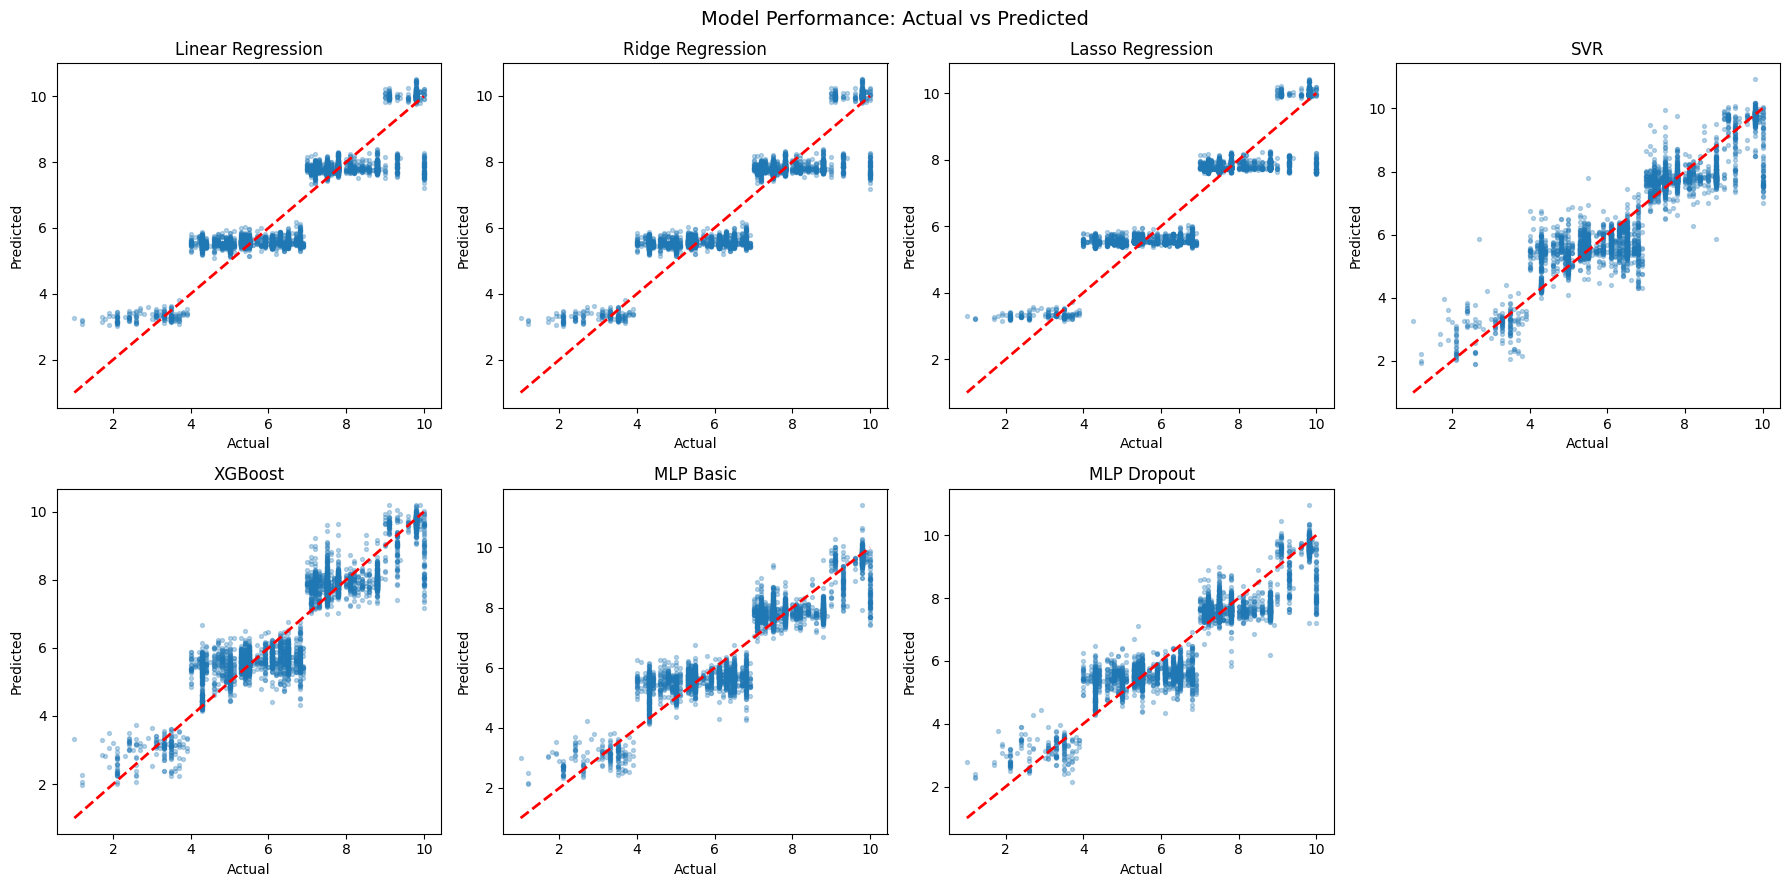

In [ ]:
model_preds = {
    "Linear Regression": preds_lr,
    "Ridge Regression": preds_ridge,
    "Lasso Regression": preds_lasso,
    "SVR": preds_svr,
    "XGBoost": preds_xgb,
    "MLP Basic": preds_mlp_basic,
    "MLP Dropout": preds_mlp_dropout
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Model Performance: Actual vs Predicted", fontsize=14)

for ax, (name, preds) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(y_test, preds, alpha=0.3, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(name)

axes[1, 3].axis("off")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/actual_vs_predicted.png", dpi=150)
plt.show()

 Residual Plots

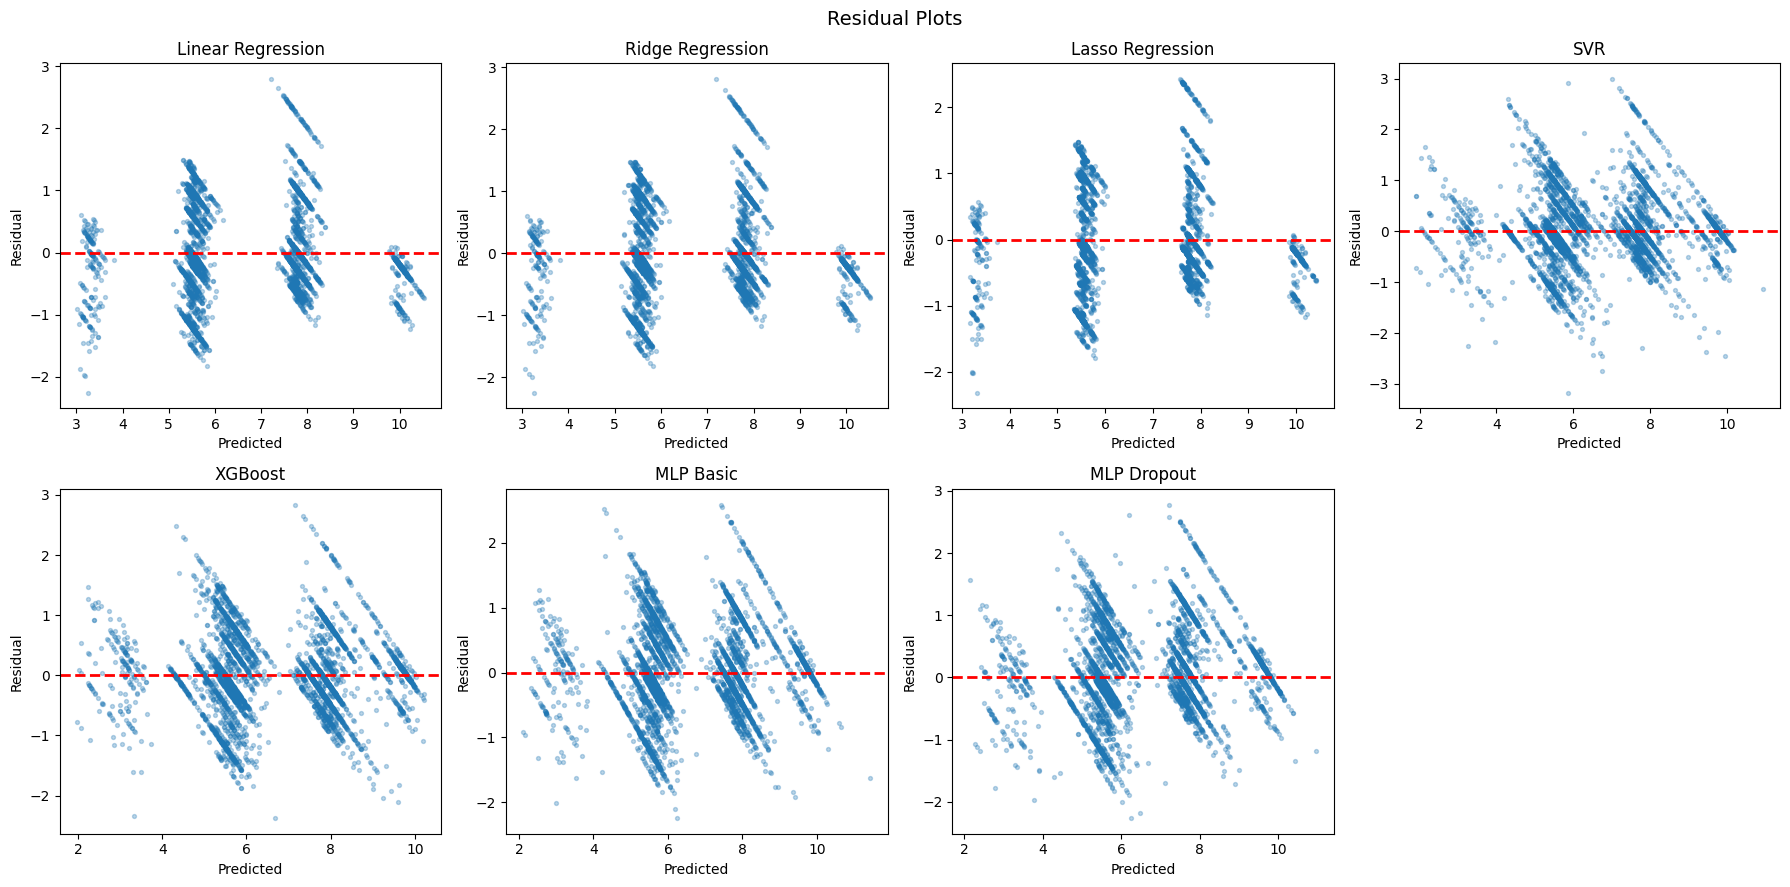

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Residual Plots", fontsize=14)

for ax, (name, preds) in zip(axes.flatten(), model_preds.items()):
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8)
    ax.axhline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(name)

axes[1, 3].axis("off")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/residual_plots.png", dpi=150)
plt.show()

Model Comparison Chart

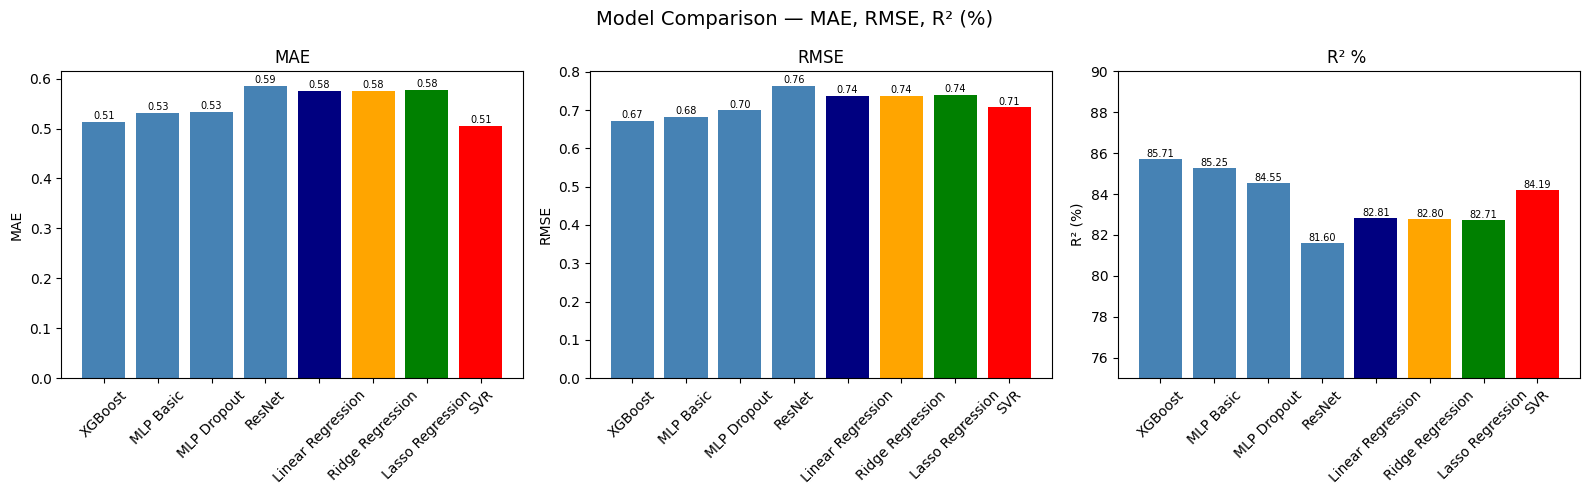

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — MAE, RMSE, R² (%)", fontsize=14)

names = list(results.keys())
maes = [results[n]["MAE"] for n in names]
rmses = [results[n]["RMSE"] for n in names]
r2s = [results[n]["R2"] * 100 for n in names]

colors = ["steelblue", "steelblue", "steelblue", "steelblue",
          "navy", "orange", "green", "red"]

axes[0].bar(names, maes, color=colors)
axes[0].set_title("MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(names, rmses, color=colors)
axes[1].set_title("RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(names, r2s, color=colors)
axes[2].set_title("R² % ")
axes[2].set_ylabel("R² (%)")
axes[2].set_ylim(75, 90)
axes[2].tick_params(axis="x", rotation=45)

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/model_comparison.png", dpi=150)
plt.show()

K-Fold CV Stability

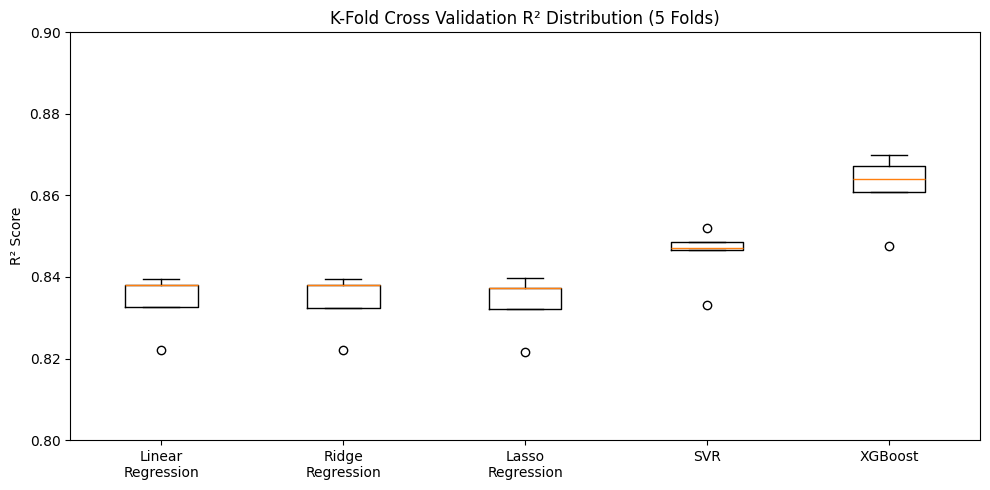

In [ ]:
cv_data = {
    "Linear\nRegression": lr_cv,
    "Ridge\nRegression": ridge_cv,
    "Lasso\nRegression": lasso_cv,
    "SVR": svr_cv,
    "XGBoost": xgb_cv
}

fig, ax = plt.subplots(figsize=(10, 5))
for pos, (name, scores) in enumerate(cv_data.items()):
    ax.boxplot(scores, positions=[pos], widths=0.4)

ax.set_xticks(list(range(len(cv_data))))
ax.set_xticklabels(list(cv_data.keys()))
ax.set_title("K-Fold Cross Validation R² Distribution (5 Folds)")
ax.set_ylabel("R² Score")
ax.set_ylim(0.80, 0.90)
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/cv_stability.png", dpi=150)
plt.show()

Feature Importance

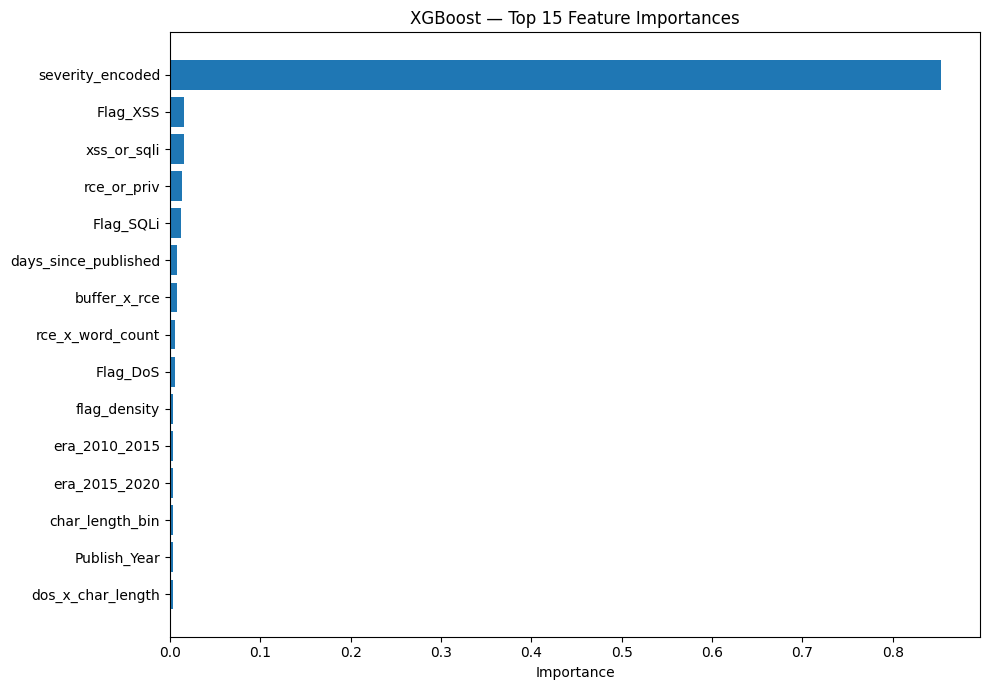

In [ ]:
feature_names = X_train.columns
xgb_importance = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(xgb_importance.index[::-1], xgb_importance.values[::-1])
ax.set_title("XGBoost — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/feature_importance.png", dpi=150)
plt.show()

Deep Learning Training History

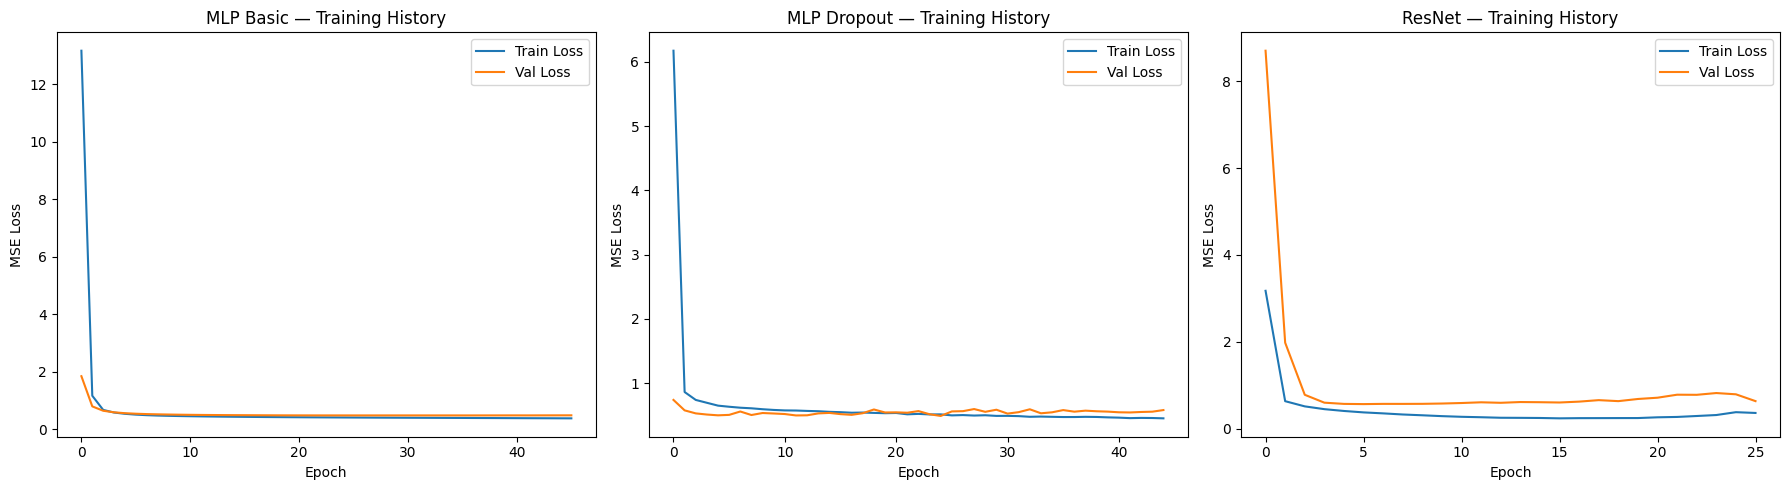

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_basic.history["loss"], label="Train Loss")
axes[0].plot(history_basic.history["val_loss"], label="Val Loss")
axes[0].set_title("MLP Basic — Training History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].plot(history_dropout.history["loss"], label="Train Loss")
axes[1].plot(history_dropout.history["val_loss"], label="Val Loss")
axes[1].set_title("MLP Dropout — Training History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

axes[2].plot(history_resnet.history["loss"], label="Train Loss")
axes[2].plot(history_resnet.history["val_loss"], label="Val Loss")
axes[2].set_title("ResNet — Training History")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MSE Loss")
axes[2].legend()

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/deep_learning_history.png", dpi=150)
plt.show()

**CVSS Scoring Inconsistency Detection (Novel Contribution)**

XGBoost has learned what a consistent CVSS score looks like given a vulnerability's attributes. CVEs where the actual score deviates significantly from the model prediction are flagged as potentially inconsistently scored by analysts.

Method:
- Generate predictions on the full 20,000 record dataset using the trained XGBoost model
- Compute residuals (actual - predicted) for each record
- Set the inconsistency threshold at the 90th percentile of absolute residuals (±0.91)
- Flag all records exceeding this threshold as inconsistent
- Analyse flag rates by severity band to identify where inconsistency is most prevalent

This application of the model as an auditing tool is not present in any benchmark paper and represents a novel contribution of this study.

Inconsistency Detection

Inconsistency threshold (90th percentile): 0.9206

Total CVEs flagged: 2000
That is 10.0% of the dataset

Inconsistency rate by severity band:
               total  flagged  flag_rate
severity_band                           
CRITICAL        2518      192     0.0763
HIGH            7189      334     0.0465
LOW              876       40     0.0457
MEDIUM          9417     1434     0.1523


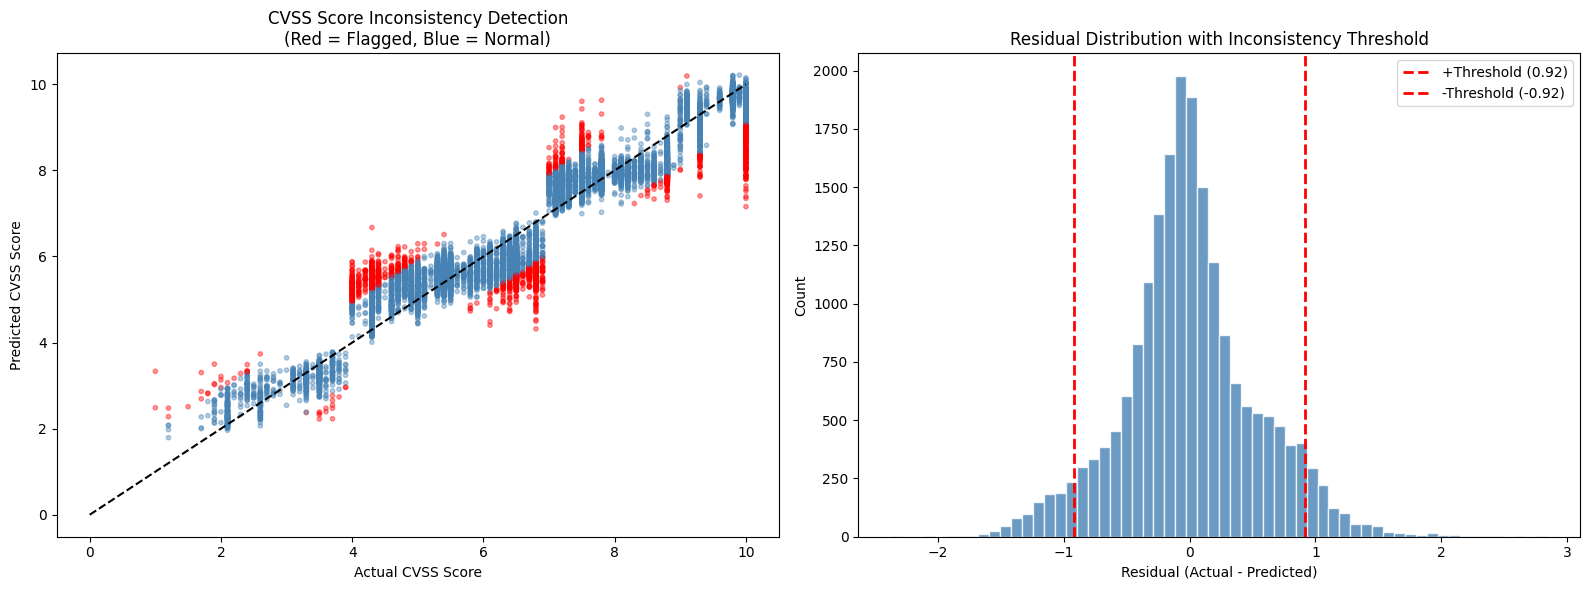

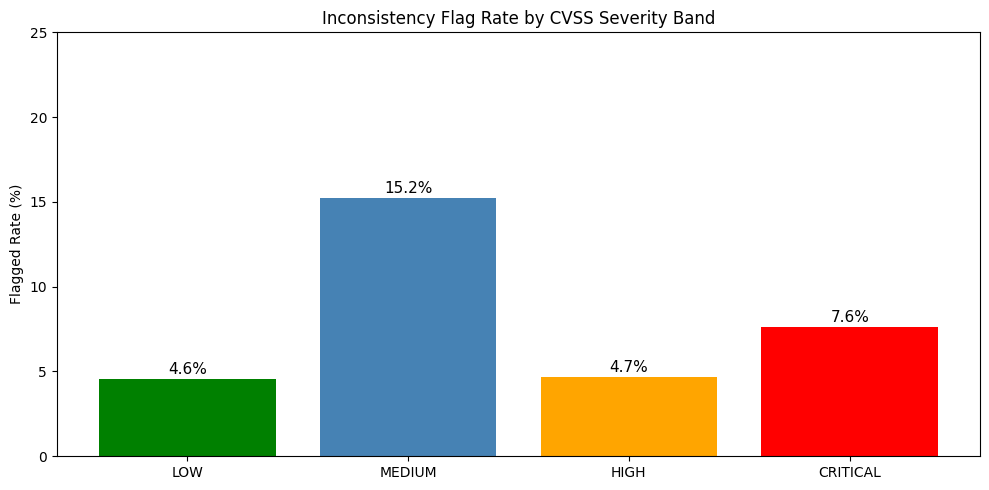


Flagged CVEs saved.


In [ ]:
X_full = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_engineered_20k.csv")
y_full = X_full.pop("CVSS_Base_Score")

predicted_scores = xgb.predict(X_full)
actual_scores = y_full.values
residuals = actual_scores - predicted_scores
abs_residuals = np.abs(residuals)

threshold = np.percentile(abs_residuals, 90)
print(f"Inconsistency threshold (90th percentile): {threshold:.4f}")

df_raw = pd.read_csv("/drive/MyDrive/Colab Notebooks/NVD_sample_20k.csv")

inconsistency_df = pd.DataFrame({
    "cve_id": df_raw["CVE_ID"].values,
    "actual_score": actual_scores,
    "predicted_score": predicted_scores.round(4),
    "residual": residuals.round(4),
    "abs_residual": abs_residuals.round(4),
    "flagged": abs_residuals > threshold
})

def score_to_severity(score):
    if score >= 9.0: return "CRITICAL"
    elif score >= 7.0: return "HIGH"
    elif score >= 4.0: return "MEDIUM"
    else: return "LOW"

inconsistency_df["severity_band"] = inconsistency_df["actual_score"].apply(score_to_severity)

print(f"\nTotal CVEs flagged: {inconsistency_df['flagged'].sum()}")
print(f"That is {inconsistency_df['flagged'].mean()*100:.1f}% of the dataset")

severity_analysis = inconsistency_df.groupby("severity_band").agg(
    total=("flagged", "count"),
    flagged=("flagged", "sum"),
    flag_rate=("flagged", "mean")
).round(4)
print("\nInconsistency rate by severity band:")
print(severity_analysis)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = inconsistency_df["flagged"].map({True: "red", False: "steelblue"})
axes[0].scatter(inconsistency_df["actual_score"], inconsistency_df["predicted_score"], c=colors, alpha=0.4, s=10)
axes[0].plot([0, 10], [0, 10], 'k--', lw=1.5)
axes[0].set_xlabel("Actual CVSS Score")
axes[0].set_ylabel("Predicted CVSS Score")
axes[0].set_title("CVSS Score Inconsistency Detection\n(Red = Flagged, Blue = Normal)")

axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(threshold, color="red", linestyle="--", lw=2, label=f"+Threshold ({threshold:.2f})")
axes[1].axvline(-threshold, color="red", linestyle="--", lw=2, label=f"-Threshold (-{threshold:.2f})")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution with Inconsistency Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/inconsistency_detection.png", dpi=150)
plt.show()

severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
flag_rates = [severity_analysis.loc[s, "flag_rate"] * 100 for s in severity_order if s in severity_analysis.index]
colors_bar = ["green", "steelblue", "orange", "red"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(severity_order, flag_rates, color=colors_bar)
ax.set_ylabel("Flagged Rate (%)")
ax.set_title("Inconsistency Flag Rate by CVSS Severity Band")
ax.set_ylim(0, 25)
for bar, rate in zip(bars, flag_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{rate:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("/drive/MyDrive/Colab Notebooks/inconsistency_by_severity.png", dpi=150)
plt.show()

inconsistency_df[inconsistency_df["flagged"]].sort_values("abs_residual", ascending=False).to_csv(
    "/drive/MyDrive/Colab Notebooks/flagged_inconsistent_cves.csv", index=False
)
print("\nFlagged CVEs saved.")

 Save Models

In [ ]:
joblib.dump(lr, "/drive/MyDrive/Colab Notebooks/linear_regression.model")
joblib.dump(ridge, "/drive/MyDrive/Colab Notebooks/ridge_regression.model")
joblib.dump(lasso, "/drive/MyDrive/Colab Notebooks/lasso_regression.model")
joblib.dump(svr, "/drive/MyDrive/Colab Notebooks/svr.model")
joblib.dump(xgb, "/drive/MyDrive/Colab Notebooks/xgboost.model")
mlp_basic.save("/drive/MyDrive/Colab Notebooks/mlp_basic.keras")
mlp_dropout.save("/drive/MyDrive/Colab Notebooks/mlp_dropout.keras")
resnet.save("/drive/MyDrive/Colab Notebooks/resnet.keras")

with open("/drive/MyDrive/Colab Notebooks/linear_regression.pkl", "wb") as f:
    pickle.dump(lr, f)
with open("/drive/MyDrive/Colab Notebooks/ridge_regression.pkl", "wb") as f:
    pickle.dump(ridge, f)
with open("/drive/MyDrive/Colab Notebooks/lasso_regression.pkl", "wb") as f:
    pickle.dump(lasso, f)
with open("/drive/MyDrive/Colab Notebooks/svr.pkl", "wb") as f:
    pickle.dump(svr, f)
with open("/drive/MyDrive/Colab Notebooks/xgboost.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("All 8 models saved successfully.")
print("Sklearn models: .model and .pkl formats")
print("Keras models: .keras format")

All 8 models saved successfully.
Sklearn models: .model and .pkl formats
Keras models: .keras format
